モデル番号: [3, 2, 0, 1, 20, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
正解率: [0.2698612862547289, 0.8002735978112175, 0.9175977653631285, 0.9817232375979112, 0.9983606557377049, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
ソート後のモデル番号: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 20, 1, 0, 2, 3]
ソート後の正解率: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9983606557377049, 0.9817232375979112, 0.9175977653631285, 0.8002735978112175, 0.2698612862547289]
正解データ数: [716, 766, 731, 793, 232, 174, 168, 160, 185, 210, 292, 331, 551, 599, 543, 306, 372, 251, 592, 706, 610, 213, 221, 197, 210, 322, 168, 267, 239, 292, 414]
ソート後の正解データ数: [232, 174, 168, 160, 185, 210, 292, 331, 551, 599, 543, 306, 372, 251, 592, 706, 213, 221, 197, 2

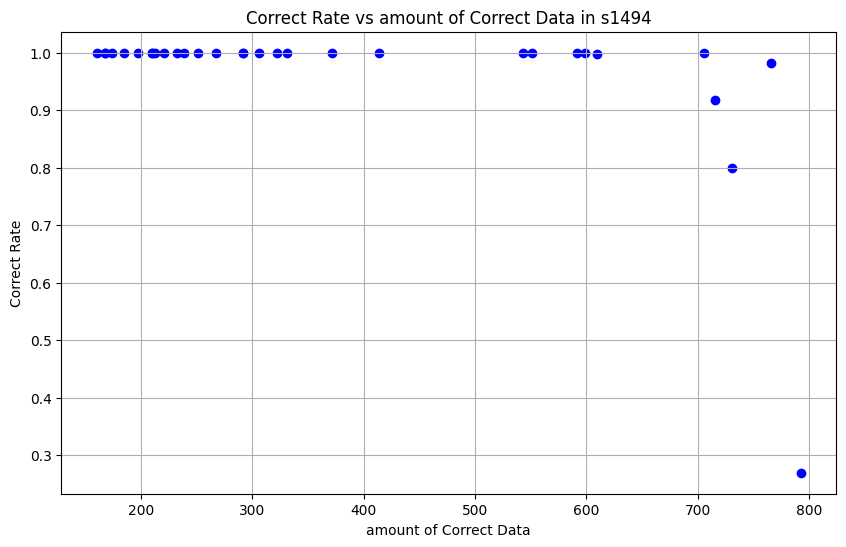

In [7]:
# 各モデルにおける正解データ数と正解率の関係をグラフで表示するプログラム


#グローバル変数
cir = 's1494'  # 対象回路
correct_rate_data_file = cir + 'model_correct_rate_sorted'  # 正解率データファイル
correct_data_num_file = cir + '分割正解データ削除後2/' + cir + 'delited_data_num'  # 正解データ数ファイル



with open(correct_rate_data_file, 'r') as f:  # 正解率データファイルを開く
    lines = [l.strip() for l in f.readlines() if l.strip()]  # 空行除去
    model_id = [int(lines[i].replace("モデル", "")) for i in range(0, len(lines), 2)] # モデルの番号を取得
    correct_rate = [float(lines[i].replace("正解率", "")) for i in range(1, len(lines), 2)]  # 各モデルの正解率を取得

print("モデル番号:", model_id)
print("正解率:", correct_rate)


# correct_rate を降順にソートし、対応する model_id も同順に並べる
sorted_pairs = sorted(zip(model_id, correct_rate), key=lambda x:x[1], reverse=True) # (model_id, rate) のリストを rate で降順ソートし、タプルのリストを作成
if sorted_pairs:
    model_id_sorted, correct_rate_sorted = map(list, zip(*sorted_pairs)) # ソート後の model_id と correct_rate を分離
else:  # 空リストの場合の処理
    model_id_sorted, correct_rate_sorted = [], []

print("ソート後のモデル番号:", model_id_sorted)
print("ソート後の正解率:", correct_rate_sorted)


with open(correct_data_num_file, 'r') as f:  # 正解データ数ファイルを開く
    for i in range(4): # 最初の4行はスキップ
        line = f.readline().strip()

    lines = f.readlines()
    correct_data_num = [int(line.strip().split(':')[1]) for line in lines]  # 各モデルの正解データ数を取得.「:」以降の数値部分のみ抽出

print("正解データ数:", correct_data_num)

correct_data_num_sorted = []
for mid in model_id_sorted:
    try:
        correct_data_num_sorted.append(correct_data_num[mid])
    except IndexError:
        correct_data_num_sorted.append(0)

print("ソート後の正解データ数:", correct_data_num_sorted)



# 正解データ数と正解率の関係をグラフで表示
#　縦を正解率，横を正解データ数とする
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6)) # グラフのサイズを指定
plt.scatter(correct_data_num_sorted, correct_rate_sorted, color='blue') # 散布図を作成
plt.title(f'Correct Rate vs amount of Correct Data in {cir}') # グラフのタイトル
plt.xlabel('amount of Correct Data') # x軸のラベル
plt.ylabel('Correct Rate') # y軸のラベル
plt.grid(True) # グリッドを表示
plt.savefig(cir + 'correct_rate_vs_data_num.png') # グラフを画像ファイルとして保存
plt.show() # グラフを表示
